In [2]:
# Question 1: Analyze customer purchase patterns
# The sales file contains quantity, unit price, and date, so purchase amount is calculated.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make the notebook work whether its kernel starts in the workspace or notebook folder.
DATA_DIR = Path("DATA")
if not DATA_DIR.exists():
    DATA_DIR = Path.cwd().parent / "DATA"

sales = pd.read_csv(DATA_DIR / "sales - sales.csv", parse_dates=["Date"])
sales["purchase_amount"] = sales["Quantity"] * sales["UnitPrice"]
sales["month"] = sales["Date"].dt.to_period("M")

# Average monthly spending for each customer.
monthly_spending = (
    sales.groupby(["CustomerID", "month"], as_index=False)["purchase_amount"]
    .sum()
)
average_monthly_spending = (
    monthly_spending.groupby("CustomerID", as_index=False)["purchase_amount"]
    .mean()
    .rename(columns={"purchase_amount": "average_monthly_spending"})
)
print(average_monthly_spending)


   CustomerID  average_monthly_spending
0        C001                    1500.0
1        C002                    1850.0
2        C003                    1950.0
3        C004                   22000.0
4        C005                    2400.0
5        C006                    3500.0
6        C007                    2500.0
7        C008                    3600.0
8        C009                    2500.0
9        C010                    6000.0
10       C011                   12500.0
11       C012                     900.0
12       C013                    9500.0
13       C014                   18000.0
14       C015                    3200.0
15       C016                    2200.0
16       C017                    6400.0
17       C018                    1100.0
18       C019                     750.0
19       C020                   14500.0


In [3]:
# Question 2: Identify missing values and impute them
# Numeric missing values are filled with the median; text values use the mode.
missing_customers = pd.read_csv(DATA_DIR / "missing_customers - missing_customers (1).csv")
print("Missing values before imputation:\n", missing_customers.isna().sum())

for column in missing_customers.select_dtypes(include=np.number).columns:
    missing_customers[column] = missing_customers[column].fillna(missing_customers[column].median())
for column in missing_customers.select_dtypes(exclude=np.number).columns:
    if missing_customers[column].isna().any():
        missing_customers[column] = missing_customers[column].fillna(missing_customers[column].mode()[0])

print("\nMissing values after imputation:\n", missing_customers.isna().sum())
print(missing_customers.head())


Missing values before imputation:
 CustomerID      0
Name            0
Gender          2
Age             4
AnnualIncome    3
LoyaltyScore    1
Membership      0
dtype: int64

Missing values after imputation:
 CustomerID      0
Name            0
Gender          0
Age             0
AnnualIncome    0
LoyaltyScore    0
Membership      0
dtype: int64
   CustomerID    Name  Gender   Age  AnnualIncome  LoyaltyScore Membership
0         101  Anjali  Female  25.0       50000.0           7.0     Silver
1         102    Ravi    Male  34.0       62000.0           8.0       Gold
2         103   Meena  Female  30.5       57000.0           6.0     Silver
3         104   Sohan    Male  29.0       61000.0           9.0       Gold
4         105   Geeta  Female  31.0       49000.0           7.0   Platinum


In [4]:
# Question 3: Filter and sort employee records
# Select IT employees earning more than 60K and sort them by salary descending.
employees = pd.read_csv(DATA_DIR / "employee_salaries - employee_salaries.csv")
it_high_salary = employees[
    (employees["department"].eq("IT")) & (employees["salary_in_k"] > 60)
].sort_values("salary_in_k", ascending=False)
print(it_high_salary)


    employee_id department  salary_in_k
26         E027         IT           69
63         E064         IT           68
89         E090         IT           68
31         E032         IT           68
7          E008         IT           68
..          ...        ...          ...
57         E058         IT           61
150        E151         IT           61
126        E127         IT           61
176        E177         IT           61
199        E200         IT           61

[69 rows x 3 columns]


In [5]:
# Question 4: Calculate statistical metrics for stock-like price data
# No stock dataset is present, so UnitPrice from product_sales is used as the available price series.
product_sales = pd.read_csv(DATA_DIR / "product_sales - product_sales.csv")
price_series = product_sales["UnitPrice"].dropna()
stock_statistics = pd.Series(
    {
        "mean": np.mean(price_series),
        "median": np.median(price_series),
        "standard_deviation": np.std(price_series, ddof=1),
    }
)
print(stock_statistics)


mean                  1239.000000
median                1325.000000
standard_deviation     250.681177
dtype: float64


In [6]:
# Question 5: Create a pivot table for sales analysis
# The pivot table summarizes total sales for every region and product category.
product_sales["TotalSales"] = product_sales["UnitPrice"] * product_sales["QuantitySold"]
sales_pivot = pd.pivot_table(
    product_sales,
    values="TotalSales",
    index="Region",
    columns="Category",
    aggfunc="sum",
    fill_value=0,
)
print(sales_pivot)


Category  Electronics  Fashion   Home
Region                               
East            15000    27900  30920
North           35550    25750  15130
South           33320    29050  14700
West            45750    12600  23730


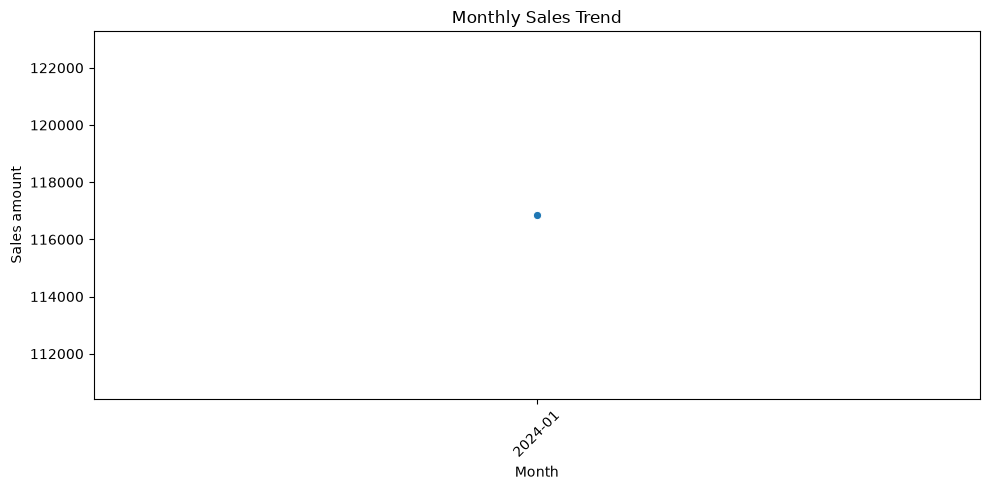

In [7]:
# Question 6: Plot monthly sales
# Convert dates to monthly periods and plot the total purchase amount per month.
sales_by_month = sales.groupby("month", as_index=False)["purchase_amount"].sum()
sales_by_month["month"] = sales_by_month["month"].astype(str)

plt.figure(figsize=(10, 5))
sns.lineplot(data=sales_by_month, x="month", y="purchase_amount", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


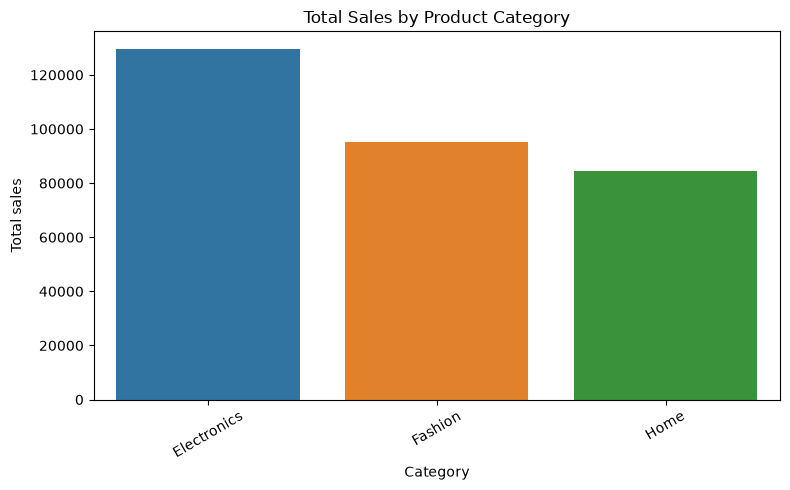

In [8]:
# Question 7: Compare category sales with a bar chart
# Aggregate sales by category before drawing the comparison chart.
category_sales = product_sales.groupby("Category", as_index=False)["TotalSales"].sum()

plt.figure(figsize=(8, 5))
sns.barplot(data=category_sales, x="Category", y="TotalSales", hue="Category", legend=False)
plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


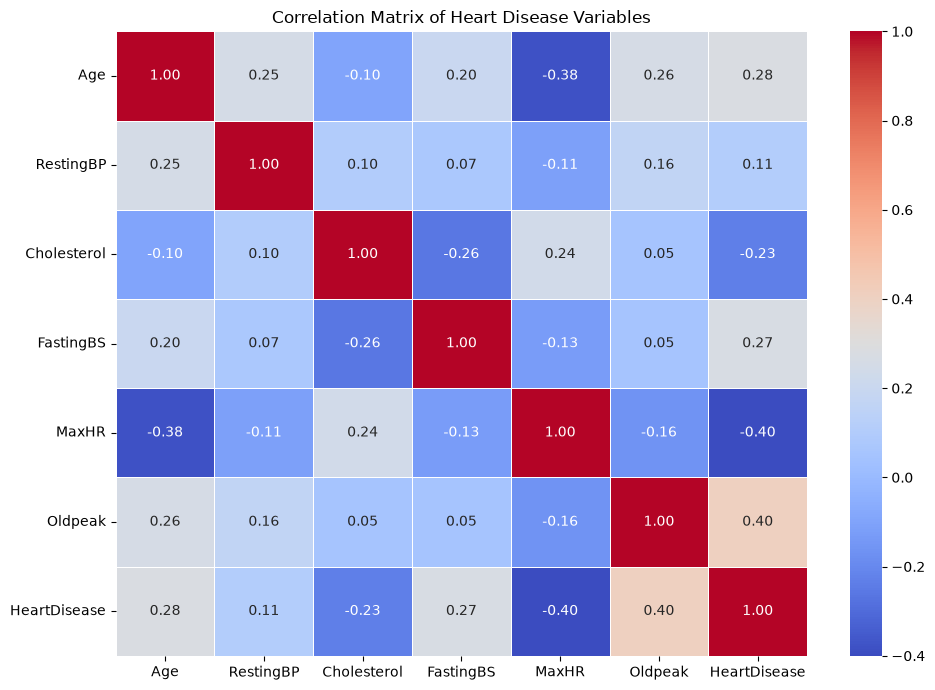

In [9]:
# Question 8: Visualize correlations using a heatmap
# Correlation is calculated only for numeric columns in the heart disease dataset.
heart = pd.read_csv(DATA_DIR / "heart.csv")
correlation_matrix = heart.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Heart Disease Variables")
plt.tight_layout()
plt.show()


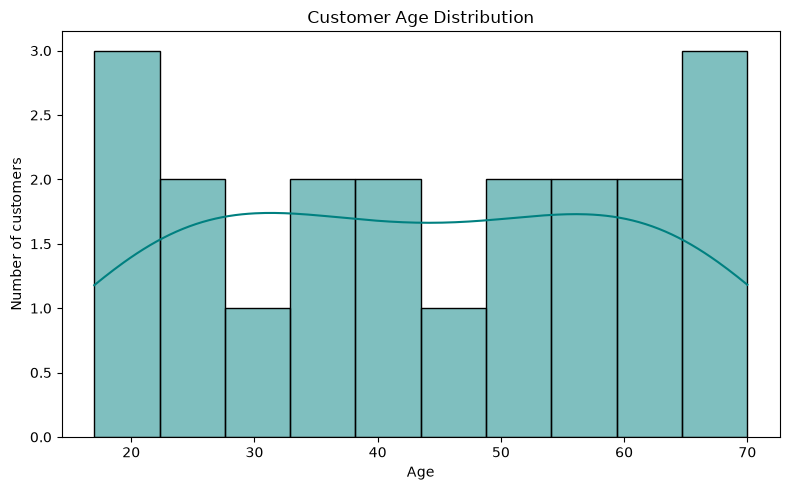

In [10]:
# Question 9: Visualize age distribution using a histogram
# The ages dataset provides customer ages for the distribution plot.
ages = pd.read_csv(DATA_DIR / "ages - ages.csv")

plt.figure(figsize=(8, 5))
sns.histplot(data=ages, x="Age", bins=10, kde=True, color="teal")
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()


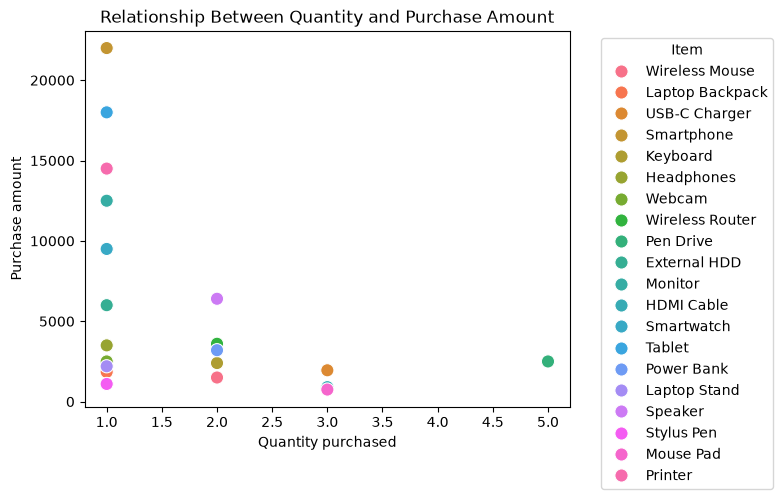

In [11]:
# Question 10: Show the relationship between two sales variables
# No advertising-budget column exists in DATA, so quantity and calculated purchase amount
# are used as the closest available sales relationship.
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sales, x="Quantity", y="purchase_amount", hue="Item", s=90)
plt.title("Relationship Between Quantity and Purchase Amount")
plt.xlabel("Quantity purchased")
plt.ylabel("Purchase amount")
plt.legend(title="Item", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
